### モデルの推定

市場ポートフォリオ: S&P500

安全資産: アメリカ10年国債

In [2]:
# S&P500のデータ

import pandas as pd

df_price = pd.read_csv("data_05/stock_price.csv", index_col='Date')
df_price.head()

# "MCD"はMcDonaldの株価

,SP500,MCD
Date,,
2016-06-06,2109.409912,107.549301
2016-06-07,2112.129883,107.461159
2016-06-08,2119.120117,107.646301
2016-06-09,2115.479980,108.245735
2016-06-10,2096.070068,107.866676


In [3]:
# アメリカ10年国債のデータ

df_interest_data = pd.read_csv("data_05/interest_rate.csv", index_col='Date')
df_interest_data.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2016-06-06,1.742,1.713,1.721,1.723,0.0,1.723
2016-06-07,1.726,1.704,1.726,1.713,0.0,1.713
2016-06-08,1.716,1.697,1.716,1.706,0.0,1.706
2016-06-09,1.683,1.659,1.676,1.680,0.0,1.680
2016-06-10,1.661,1.627,1.658,1.639,0.0,1.639


In [4]:
# リターンの計算

df_rate = df_price.pct_change()
display(df_rate)

# 最初のデータがNaNなのは2016-06-05のデータがないから

,SP500,MCD
Date,,
2016-06-06,NaN,NaN
2016-06-07,0.001289,-0.000820
2016-06-08,0.003310,0.001723
2016-06-09,-0.001718,0.005569
2016-06-10,-0.009175,-0.003502
...,...,...
2021-05-27,0.001165,0.010803
2021-05-28,0.000769,0.001370
2021-06-01,-0.000492,-0.002779


In [5]:
# 市場ポートフォリオと株価のリターンに金利データを結合

df_rate = pd.concat([df_rate, df_interest_data['Adj Close']], axis=1, join='inner')
df_rate.columns = ['SP500', 'MCD', '^TNX']
display(df_rate)

,SP500,MCD,^TNX
Date,,,
2016-06-06,NaN,NaN,1.723
2016-06-07,0.001289,-0.000820,1.713
2016-06-08,0.003310,0.001723,1.706
2016-06-09,-0.001718,0.005569,1.680
2016-06-10,-0.009175,-0.003502,1.639
...,...,...,...
2021-05-27,0.001165,0.010803,1.610
2021-05-28,0.000769,0.001370,1.581
2021-06-01,-0.000492,-0.002779,1.615


In [6]:
# リスク・プレミアムの計算
# 1年を255日として計算
# 金利は%表示なので0.01を乗算

df_rp = pd.DataFrame()
df_rp['SP500'] = df_rate['SP500'] - df_rate['^TNX'] * 0.01 / 255 
df_rp['MCD'] = df_rate['MCD'] - df_rate['^TNX'] * 0.01 / 255
display(df_rp)

,SP500,MCD
Date,,
2016-06-06,NaN,NaN
2016-06-07,0.001222,-0.000887
2016-06-08,0.003243,0.001656
2016-06-09,-0.001784,0.005503
2016-06-10,-0.009239,-0.003566
...,...,...
2021-05-27,0.001102,0.010740
2021-05-28,0.000707,0.001308
2021-06-01,-0.000556,-0.002842


In [7]:
# そろそろ邪魔になってきたNaNを除去

df_rp = df_rp.dropna()
display(df_rp)

,SP500,MCD
Date,,
2016-06-07,0.001222,-0.000887
2016-06-08,0.003243,0.001656
2016-06-09,-0.001784,0.005503
2016-06-10,-0.009239,-0.003566
2016-06-13,-0.008179,0.005085
...,...,...
2021-05-27,0.001102,0.010740
2021-05-28,0.000707,0.001308
2021-06-01,-0.000556,-0.002842


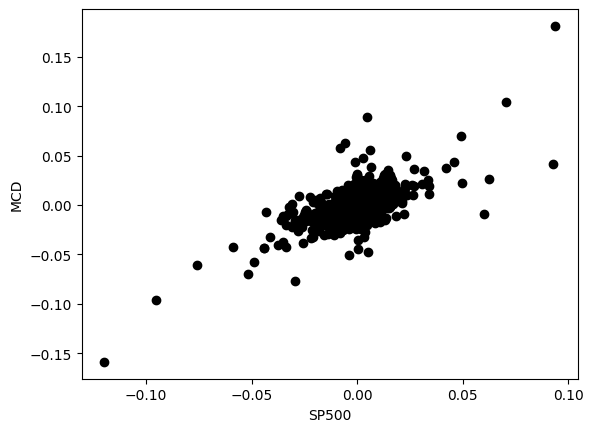

In [8]:
# 外れ値があるかチェック
# 一旦散布図にして様子を見る

import matplotlib.pyplot as plt

plt.scatter(df_rp['SP500'], df_rp['MCD'], color='black')
plt.xlabel('SP500')
plt.ylabel('MCD')
plt.show()

# データがある程度右肩上がりの直線上になっている模様
# とりあえずこのままのデータで進める

In [9]:
# 訓練データとテストデータの分割
# テストデータの比率は20%

from sklearn.model_selection import train_test_split

val_size = 0.2
df_train, df_val = train_test_split(df_rp, test_size=val_size, shuffle=False)
print(df_train.shape)
print(df_val.shape)

(996, 2)
(249, 2)


In [10]:
# 特徴量(S&P500)と目的変数(McDonald)の設定

X_train = df_train.sort_values('SP500')['SP500']
X_val = df_val.sort_values('SP500')['SP500']
y_train = df_train.sort_values('SP500')['MCD']
y_val = df_val.sort_values('SP500')['MCD']

In [11]:
# 1次の回帰

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train.values.reshape(-1, 1), y_train.values)
pred_train_1 = reg.predict(X_train.values.reshape(-1, 1))

print(reg.intercept_) # 切片
print(reg.coef_) # 回帰係数

0.0002677783169442058
[0.82544637]


In [12]:
# CAPMの場合 (切片=0)

reg_0 = LinearRegression(fit_intercept=False)
reg_0.fit(X_train.values.reshape(-1, 1), y_train.values)
pred_train_0 = reg_0.predict(X_train.values.reshape(-1, 1))

print(reg_0.intercept_) # 切片は当然0になる
print(reg_0.coef_)

0.0
[0.8261595]


In [13]:
# 精度をMSEで比較

from sklearn.metrics import mean_squared_error

MSE0 = mean_squared_error(pred_train_0, y_train)
MSE1 = mean_squared_error(pred_train_1, y_train)

print(MSE0)
print(MSE1)

# わずかに切片ありの方が性能が良いt

0.00013072623392365067
0.00013065460681415815


In [14]:
# 多項式回帰
# まずは5次の多項式を用意

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=5)
X_train_poly = poly.fit_transform(X_train.values.reshape(-1, 1))
poly_reg = LinearRegression().fit(X_train_poly, y_train.values)

print(poly_reg.intercept_)
print(poly_reg.coef_)

0.0005591747261244894
[ 0.00000000e+00  5.96703298e-01 -2.09378185e+00  4.80747082e+01
  3.39018082e+02  1.71746614e+03]


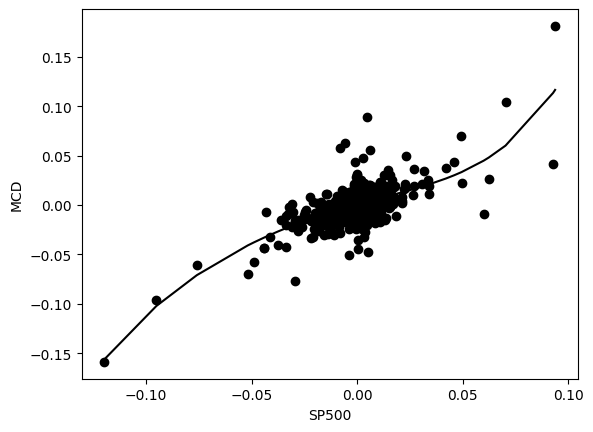

In [15]:
# 得られた5次曲線をプロット

pred_train_5 = poly_reg.predict(X_train_poly)
plt.scatter(X_train.values, y_train.values, color='black')
plt.plot(X_train.values, pred_train_5, color='black')
plt.xlabel('SP500')
plt.ylabel('MCD')
plt.show()

In [16]:
# 誤差の計算

MSE5 = mean_squared_error(pred_train_5, y_train)
print(MSE5)

# 誤差がさらに小さくなっている

0.00012051143117314137


In [17]:
# 色々と次数を変えて誤差をチェック

import numpy as np

degrees = [1, 2, 3, 4, 5, 10, 15, 20, 25]
MSE_train = np.empty(0)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train.values.reshape(-1, 1))
    poly_reg = LinearRegression().fit(X_train_poly, y_train)
    pred_train = poly_reg.predict(X_train_poly)
    MSE = mean_squared_error(pred_train, y_train)
    MSE_train = np.append(MSE_train, MSE)
    print('degree={0:d} MSE={1:e}'.format(degree, MSE))

degree=1 MSE=1.306546e-04
degree=2 MSE=1.302425e-04
degree=3 MSE=1.210581e-04
degree=4 MSE=1.205738e-04
degree=5 MSE=1.205114e-04
degree=10 MSE=1.184661e-04
degree=15 MSE=1.184774e-04
degree=20 MSE=1.184774e-04
degree=25 MSE=1.184774e-04


In [18]:
# ホールドアウト検証
# 要は時系列であることを気にしないcross-validation

MSE_val = np.empty(0)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train.values.reshape(-1, 1))
    X_val_poly = poly.fit_transform(X_val.values.reshape(-1, 1))
    poly_reg = LinearRegression().fit(X_train_poly, y_train.values)
    pred_val = poly_reg.predict(X_val_poly)
    MSE = mean_squared_error(pred_val, y_val.values)
    MSE_val = np.append(MSE_val, MSE)

    print('degree={0:d} MSE={1:e}'.format(degree, MSE))    

# 10次を超えると誤差上昇=overfitting

degree=1 MSE=9.052477e-05
degree=2 MSE=9.045131e-05
degree=3 MSE=8.383270e-05
degree=4 MSE=8.383418e-05
degree=5 MSE=8.384916e-05
degree=10 MSE=8.649483e-05
degree=15 MSE=8.649459e-05
degree=20 MSE=8.649459e-05
degree=25 MSE=8.649459e-05


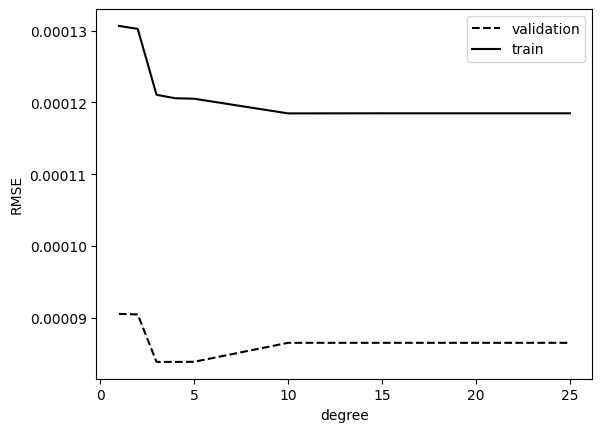

In [19]:
# 誤差のプロット

plt.plot(degrees, MSE_val, color='black', linestyle='dashed', label='validation')
plt.plot(degrees, MSE_train, color='black', linestyle='solid', label='train')
plt.xlabel('degree')
plt.ylabel("RMSE")
plt.legend(loc='best')

In [20]:
# 時系列であることを考慮したcross-validation
# ウォーク・フォワード検証(walk-forward method)というらしい

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5) # 5分割

for degree in degrees:
    MSE_train = np.empty(0)
    MSE_val = np.empty(0)
    
    for train, val in tscv.split(df_rp):
        X_train_cross = df_rp.iloc[train]['SP500']
        y_train_cross = df_rp.iloc[train]['MCD']
        X_val_cross = df_rp.iloc[val]['SP500']
        y_val_cross = df_rp.iloc[val]['MCD']
    
        poly = PolynomialFeatures(degree=degree)
        X_train_poly = poly.fit_transform(X_train_cross.values.reshape(-1, 1))
        X_val_poly = poly.fit_transform(X_val_cross.values.reshape(-1, 1))
        poly_reg = LinearRegression().fit(X_train_poly, y_train_cross)
        pred_train = poly_reg.predict(X_train_poly)
        pred_val = poly_reg.predict(X_val_poly)
        MSE_train = np.append(MSE_train, mean_squared_error(pred_train, y_train_cross))
        MSE_val = np.append(MSE_val, mean_squared_error(pred_val, y_val_cross))
        
    print('degree {0:d} MSE train {1:e} MSE val {2:e}'.format(degree, MSE_train.mean(), MSE_val.mean()))

# 10次以上の検証データでの誤差が異常

degree 1 MSE train 8.601977e-05 MSE val 1.522917e-04
degree 2 MSE train 8.592148e-05 MSE val 1.516280e-04
degree 3 MSE train 8.411899e-05 MSE val 1.348239e-04
degree 4 MSE train 8.383765e-05 MSE val 3.172046e-04
degree 5 MSE train 8.369631e-05 MSE val 3.445252e-03
degree 10 MSE train 8.275402e-05 MSE val 5.518129e+01
degree 15 MSE train 8.275649e-05 MSE val 5.518129e+01
degree 20 MSE train 8.275649e-05 MSE val 5.518129e+01
degree 25 MSE train 8.275649e-05 MSE val 5.518129e+01


In [21]:
# リッジ回帰

from sklearn.linear_model import Ridge

degree = 25 # 次数は25と高く設定
poly = PolynomialFeatures(degree=degree)
X_poly_train = poly.fit_transform(X_train.values.reshape(-1, 1))
X_poly_val = poly.fit_transform(X_val.values.reshape(-1, 1))
poly_reg = LinearRegression().fit(X_poly_train, y_train)
pred = poly_reg.predict(X_poly_val)

poly_reg_Ridge = Ridge(alpha=0.0001).fit(X_poly_train, y_train)
pred_Ridge = poly_reg_Ridge.predict(X_poly_val)

print('MSE for regression {0:e}'.format(mean_squared_error(pred, y_val)))
print('MSE for Ridge regression {0:e}'.format(mean_squared_error(pred_Ridge, y_val)))

# リッジ回帰の方がマシ

MSE for regression 8.649459e-05
MSE for Ridge regression 9.012536e-05


In [22]:
# 単なる多項式回帰の係数

print(poly_reg.coef_)

[ 1.35163757e+04  5.94933316e-01  7.26983770e+00 -1.71443443e+02
 -1.30064562e+04  2.51328415e+05  5.29563231e+06 -6.31887433e+07
 -8.40699186e+08  4.31171908e+09  4.54441058e+10 -3.52270676e+09
  1.37315436e+09 -1.20430358e+08  2.77387948e+07 -2.65150081e+06
  4.76369638e+05 -4.85046238e+04  7.55276388e+03 -8.05739858e+02
  1.14737936e+02 -1.26664708e+01  1.70202437e+00 -1.92620012e-01
  2.49083005e-02 -2.86952010e-03]


In [23]:
# リッジ回帰の係数

print(poly_reg_Ridge.coef_)

# 高次の係数が相当小さい

[ 0.00000000e+00  8.13488916e-01 -6.88238862e-01  1.58688029e+00
 -4.53990904e-02  1.90880046e-02 -9.60425283e-04  2.35838872e-04
 -1.65872969e-05  3.04713568e-06 -2.62764455e-07  4.07789889e-08
 -3.98724887e-09  5.59481643e-10 -5.91272239e-11  7.80539701e-12
 -8.65564443e-13  1.10085940e-13 -1.25767237e-14  1.56346618e-15
 -1.81935198e-16  2.23023624e-17 -2.62491404e-18  3.19011867e-19
 -3.78109243e-20  4.57095336e-21]


In [25]:
# リッジ回帰のグリッドサーチ
# 次数とリッジ回帰の係数alphaが対象

degrees = [1, 2, 3, 5, 10, 30, 50, 100, 200]
alphas = [0.01, 0.1, 1, 10, 100]

tscv = TimeSeriesSplit(n_splits=5)
min_MSE_val = np.inf
opt_deg = degrees[0]
opt_alpha = alphas[0]

for degree in degrees:
    for alpha in alphas:
        MSE_train = np.empty(0)
        MSE_val = np.empty(0)
        for train, val in tscv.split(df_rp):
            X_train_cross = df_rp.iloc[train]['SP500']
            y_train_cross = df_rp.iloc[train]['MCD']
            X_val_cross = df_rp.iloc[val]['SP500']
            y_val_cross = df_rp.iloc[val]['MCD']
    
            poly = PolynomialFeatures(degree = degree)
            X_train_poly = poly.fit_transform(X_train_cross.values.reshape(-1, 1))
            X_val_poly = poly.fit_transform(X_val_cross.values.reshape(-1, 1))
            poly_reg_Ridge = Ridge(alpha=alpha).fit(X_train_poly, y_train_cross)
            pred_train_Ridge = poly_reg_Ridge.predict(X_train_poly)
            pred_val_Ridge = poly_reg_Ridge.predict(X_val_poly)
            
            MSE_train = np.append(MSE_train, mean_squared_error(pred_train_Ridge, y_train_cross))
            MSE_val = np.append(MSE_val, mean_squared_error(pred_val_Ridge, y_val_cross))
        
        if min_MSE_val > MSE_val.mean():
            min_MSE_val = MSE_val.mean()
            opt_deg = degree
            opt_alpha = alpha
            
        print('degree {0:d} MSE train {1:e} MSE val {2:e}'.format(degree, MSE_train.mean(), MSE_val.mean()))

print('optimal degree {0:d}  optimal alpha {1:.3f}  MSE val {2:e}'.format(opt_deg, opt_alpha, min_MSE_val))

# 10次でalpha=0.01というのが最良モデルらしい

degree 1 MSE train 8.732225e-05 MSE val 1.614723e-04
degree 1 MSE train 9.577414e-05 MSE val 2.015472e-04
degree 1 MSE train 1.118342e-04 MSE val 2.355131e-04
degree 1 MSE train 1.171772e-04 MSE val 2.424260e-04
degree 1 MSE train 1.178324e-04 MSE val 2.432060e-04
degree 2 MSE train 8.731341e-05 MSE val 1.614598e-04
degree 2 MSE train 9.577190e-05 MSE val 2.015443e-04
degree 2 MSE train 1.118335e-04 MSE val 2.355125e-04
degree 2 MSE train 1.171772e-04 MSE val 2.424259e-04
degree 2 MSE train 1.178323e-04 MSE val 2.432060e-04
degree 3 MSE train 8.731206e-05 MSE val 1.614589e-04
degree 3 MSE train 9.577154e-05 MSE val 2.015442e-04
degree 3 MSE train 1.118334e-04 MSE val 2.355125e-04
degree 3 MSE train 1.171771e-04 MSE val 2.424259e-04
degree 3 MSE train 1.178323e-04 MSE val 2.432060e-04
degree 5 MSE train 8.731205e-05 MSE val 1.614588e-04
degree 5 MSE train 9.577154e-05 MSE val 2.015442e-04
degree 5 MSE train 1.118334e-04 MSE val 2.355125e-04
degree 5 MSE train 1.171771e-04 MSE val 2.4242